1. **What’s happening right now, and how fast is it moving?**
    - Epidemic curve: new cases over time (rising, plateau, declining)
    - Analyse the reproduction rate
    - Amount of time the total cases takes to double
2. **Will the health system hold, or will it collapse?**
3. **Who needs the vaccine most urgently, and are we reaching them?**


# ===================================================================
# OPERATION HEATHSHIELD
# OWID COVID-19 Analysis for Nigeria Ministry of Health
# ===================================================================

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 13
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 16
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

print("Starting Operation HealthShield - COVID-19 Analysis for Nigeria Ministry of Health")
print("="*90)
print("\n")

In [ ]:
# Load data
df = pd.read_csv("../data/covid19_compact.csv")

df = df[df["code"] == "NGA"]

# View summary statistics for numerical columns
numeric_columns = df.columns.tolist()

# Remove non-numerical columns
numeric_columns.remove("country")
numeric_columns.remove("date")

# View summary
print(df[numeric_columns].describe())

In [ ]:
## Data cleaning and transformation

# Convert the date value to a proper datetime object
df["date"] = pd.to_datetime(df["date"])

# Sort the values in the DataFrame using the date column
df = df.sort_values("date").reset_index(drop=True)

print(f"Data loaded: {len(df):,} rows from {df["date"].min().date()} to {df["date"].max().date()}")
print("\n" + "="*50 + "\n")

# Basic cleaning
# for col in numeric_columns:
#     df[col] = df[col].fillna(0)
#
# cum_fill = [
#     "total_cases", "total_deaths", "people_vaccinated_per_hundred",
#     "people_fully_vaccinated_per_hundred", "total_boosters_per_hundred"
# ]
#
# for col in cum_fill:
#     df[col] = df[col].ffill().fillna(0)

# ==========================================================================
# Objective 1: What’s happening right now, and how fast is it moving?
# ==========================================================================


OBJECTIVE 1: WHAT'S HAPPENING RIGHT NOW?


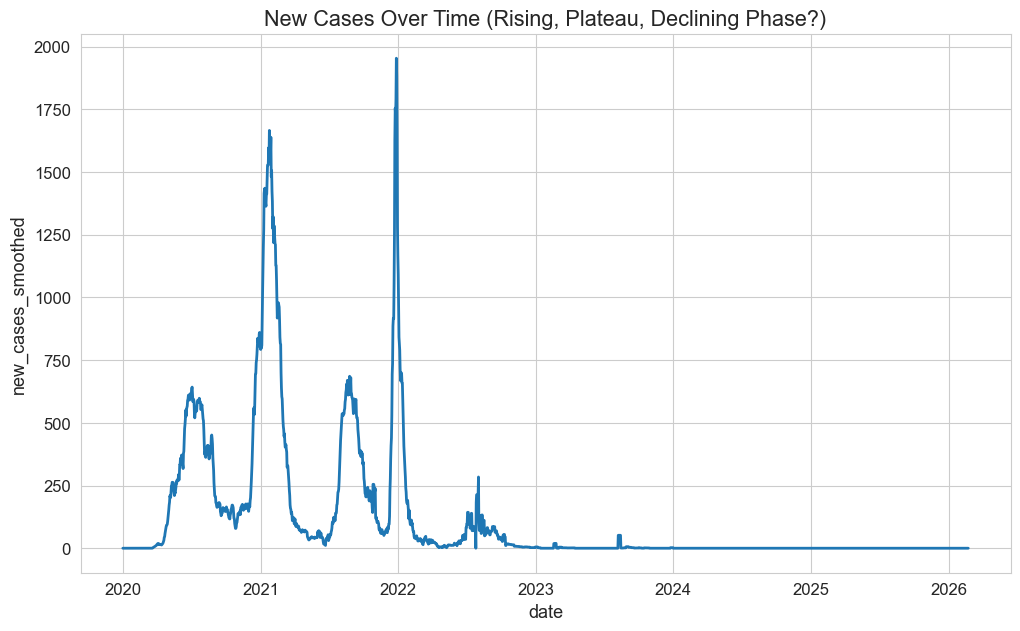

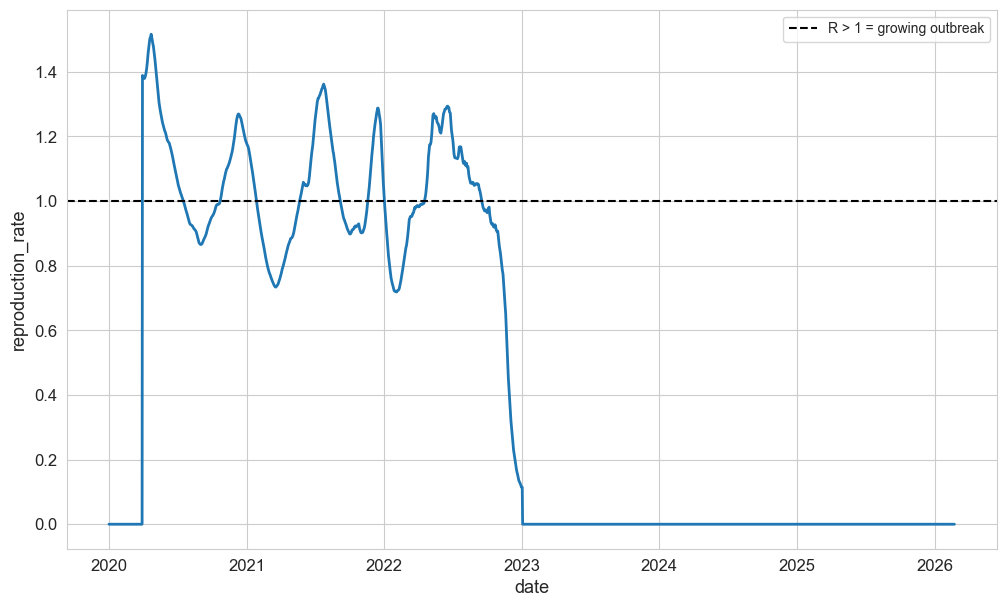

In [49]:
print("\n" + "="*70)
print("OBJECTIVE 1: WHAT'S HAPPENING RIGHT NOW?")
print("="*70)

# Epidemic Curve Analysis
plt.figure()
sns.lineplot(data=df, x="date", y="new_cases_smoothed", linewidth=2)
plt.title("New Cases Over Time (Rising, Plateau, Declining Phase?)")
plt.show()

plt.figure()
sns.lineplot(data=df, x="date", y="reproduction_rate", linewidth=2)
plt.axhline(1.0, color="black", linestyle="--", label="R > 1 = growing outbreak")
plt.legend()
plt.show()